# Fase 3 - *Comparativo*

## Tratamento de dados e configurações de plotagem

_(Pode pular essa parte)_

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

markers = pd.read_csv("./data/marcacoes.csv")
proxies = pd.read_csv("./data/proxies.csv")
markers['data'] = pd.to_datetime(markers['data'])
proxies['data'] = pd.to_datetime(proxies['data'])
markers = markers.set_index("data").sort_index()
proxies = proxies.set_index("data").sort_index()
returns = proxies.pct_change().dropna()
avg_returns = returns.mean(axis=1)
log_returns = np.log(1 + avg_returns).to_frame('MEAN')
T_10 = markers[markers['marcacao'] == 'M10'].index[0]
T_11 = markers[markers['marcacao'] == 'M11'].index[0]
M_10 = markers.loc[T_10, 'valor']
M_11 = markers.loc[T_11, 'valor']
log_returns_after_m10 = log_returns.loc[T_10:].iloc[1:]

# Ex Ante
cumsum_log_return = log_returns_after_m10.cumsum()
ex_ante_estimates = M_10 * np.exp(cumsum_log_return)
ex_ante_estimates.columns = ['MARKER_ESTIMATE']

# Ex Post
N = log_returns_after_m10.count()
alpha = (np.log(M_11 / M_10) - np.sum(log_returns_after_m10)) / N
r_star = (log_returns_after_m10 + alpha).copy()
cumsum_r_star = r_star.cumsum()
ex_post_estimates = M_10 * np.exp(cumsum_r_star)
ex_post_estimates.columns = ['MARKER_ESTIMATE']

forecasts = pd.concat([
    ex_ante_estimates['MARKER_ESTIMATE'].rename('EX_ANTE'),
    ex_post_estimates['MARKER_ESTIMATE'].rename('EX_POST')
], axis=1)

# Inserindo um primeiro datapoint com o valor inicial de M10
forecasts.loc[T_10] = [M_10, M_10]
forecasts = forecasts.sort_index()

real_markers = markers.loc[T_10:].copy()

In [105]:
def plot_1():
    sns.set_theme(style="white", rc={"axes.facecolor": "#ffffff"})
    plt.figure(figsize=(15, 8))

    # Cores Profissionais
    CLR_EX_ANTE = '#94a3b8'  # Slate Gray
    CLR_EX_POST = '#0369a1'  # Deep Blue
    CLR_MARKER = '#e11d48'   # Rose Red

    #======EX ANTE (Benchmark)===========================================
    plt.plot(forecasts.index, forecasts['EX_ANTE'],
             label="Trajetória Ex Ante (Somente Mercado)",
             color=CLR_EX_ANTE, linewidth=1.5, linestyle='--', alpha=0.8)

    #======EX POST (Ajustada)============================================
    plt.plot(forecasts.index, forecasts['EX_POST'],
             label="Trajetória Ex Post (Ancorada em M11)",
             color=CLR_EX_POST, linewidth=3)

    # Sombra de Diferença (Destaque do Ajuste)
    plt.fill_between(forecasts.index, forecasts['EX_ANTE'], forecasts['EX_POST'],
                     color=CLR_EX_POST, alpha=0.2, label="Ajuste de Drift (α)")

    #======MARCADORES REAIS==============================================
    plt.scatter(real_markers.index, real_markers['valor'],
                color=CLR_MARKER, s=150, marker='o', zorder=5,
                edgecolors='white', linewidth=2, label="Marcações Oficiais")

    # Anotações de Valor
    for i, (date, row) in enumerate(real_markers.iterrows()):
        va = 'bottom' if i == 0 else 'top'
        offset = 15 if i == 0 else -25
        plt.annotate(f"{row['marcacao']}\nR$ {row['valor']:.2f}",
                     (date, row['valor']),
                     textcoords="offset points", xytext=(0, offset),
                     ha='center', fontsize=11, fontweight='bold', color=CLR_MARKER)

    #======CONFIGURAÇÃO FINAL============================================
    plt.title('Reconciliação de Valor: Estimativa de Mercado vs. Marcação Real',
              fontsize=18, fontweight='bold', pad=30, loc='left', color='#1e293b')

    plt.ylabel('Empresa Asset Value (BRL)', fontsize=12, color='#64748b')
    plt.legend(loc='upper left', frameon=False, fontsize=10)

    sns.despine(left=True, bottom=True)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_2():
    forecasts['DIVERGENCE_PCT'] = (forecasts['EX_POST'] / forecasts['EX_ANTE'] - 1) * 100

    plt.figure(figsize=(15, 5))
    plt.fill_between(forecasts.index, forecasts['DIVERGENCE_PCT'], 0,
                     where=(forecasts['DIVERGENCE_PCT'] >= 0), color='#10b981', alpha=0.3)
    plt.fill_between(forecasts.index, forecasts['DIVERGENCE_PCT'], 0,
                     where=(forecasts['DIVERGENCE_PCT'] < 0), color='#ef4444', alpha=0.3)

    plt.plot(forecasts.index, forecasts['DIVERGENCE_PCT'], color='#475569', linewidth=2)
    plt.axhline(0, color='black', linewidth=1, linestyle='-')

    plt.title('Divergência Acumulada (%): Ativo vs. Benchmark de Mercado', fontsize=15, fontweight='bold')
    plt.ylabel('Spread (%)')
    sns.despine(left=True, bottom=True)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

def plot_3():
    total_return = (M_11 / M_10) - 1
    market_return = np.exp(log_returns_after_m10.sum().iloc[0]) - 1
    rho = total_return - market_return

    attribution = pd.Series({
        'Retorno Total (M10-M11)': total_return,
        'Efeito Mercado (OLEO3 + FUEL3)': market_return,
        'Efeito Idiossincrático (Empresa)': rho,
    }) * 100

    print("--- Atribuição de Performance (%) ---")
    print(attribution)

    plt.figure(figsize=(10, 6))

    colors = ['#0077b6' if x > 0 else '#d62828' for x in attribution[:2]]

    attribution.plot(kind='bar', color=colors, alpha=0.5)

    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('Decomposição do Retorno (M10 a M11)')
    plt.ylabel('Variação Percentual (%)')
    plt.xticks(rotation=0)

    sns.despine(left=True, bottom=True)
    plt.grid(False)
    plt.show()


## Plotagem das séries de previsão

Temos o dataframe `forecasts` que contém ambas as previsões _Ex Ante_ e _Ex Post_, além dos valores reais de $M_{10}$ e $M_{11}$. Abaixo, vamos plotar os dados:

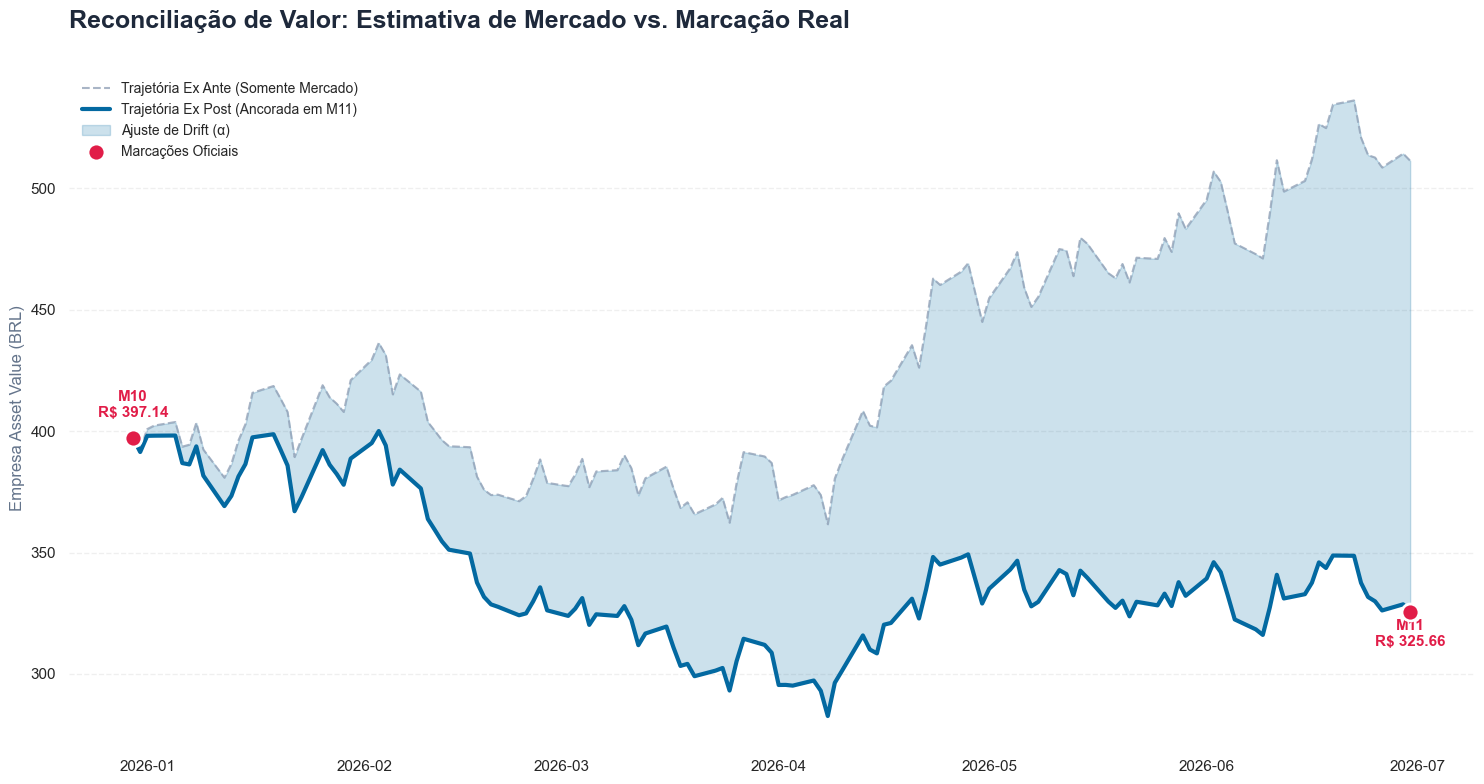

In [106]:
plot_1()


## Gráfico de Divergências

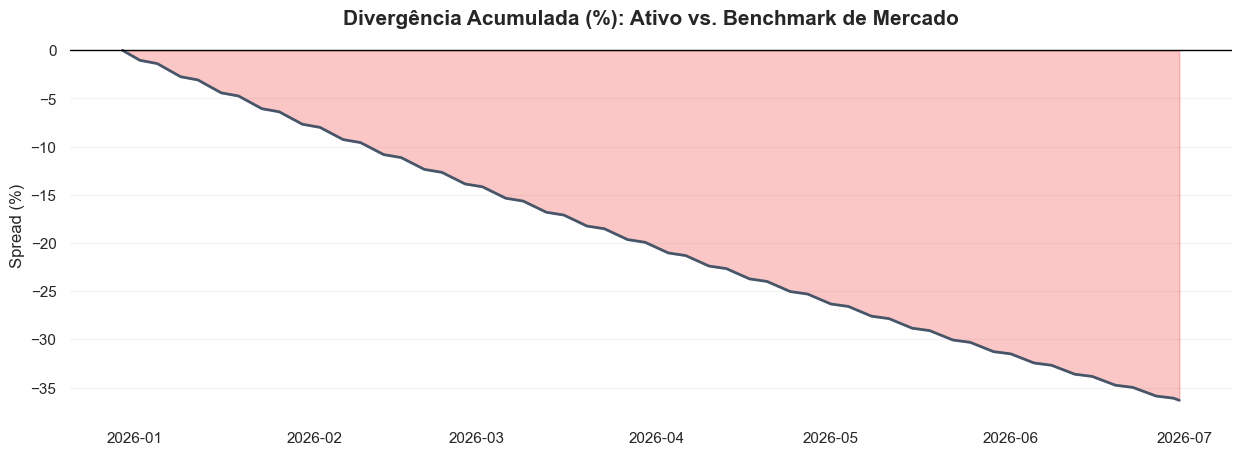

In [107]:
plot_2()

## Análise do efeito idiossincrático e Atribuição

Os dados demonstram que houve um descolamento entre o preço dos marcadores e as proxies de mercado. Para quantificar esse efeito de forma robusta, utilizamos a decomposição dos log-retornos (retornos contínuos), que permitem uma atribuição aditiva e precisa.

Consideremos o log-retorno total da empresa entre $M_{10}$ e $M_{11}$:

$$
r_{\text{TOTAL}} = \ln\left(\frac{M_{11}}{M_{10}}\right)
$$

E o log-retorno acumulado do mercado (benchmark das proxies):

$$
r_{\text{MERCADO}} = \sum_{t = T_{10}}^{T_{11}} r_t
$$

O efeito idiossincrático ($\rho_{log}$) é a parcela do retorno que não é explicada pelo movimento das proxies, correspondendo ao somatório do ajuste de drift ($\alpha$) aplicado no modelo Ex Post:

$$
\rho_{log} = r_{\text{TOTAL}} - r_{\text{MERCADO}} = N \cdot \alpha
$$

--- Atribuição de Performance (%) ---
Retorno Total (M10-M11)            -17.998691
Efeito Mercado (OLEO3 + FUEL3)      28.768130
Efeito Idiossincrático (Empresa)   -46.766821
dtype: float64


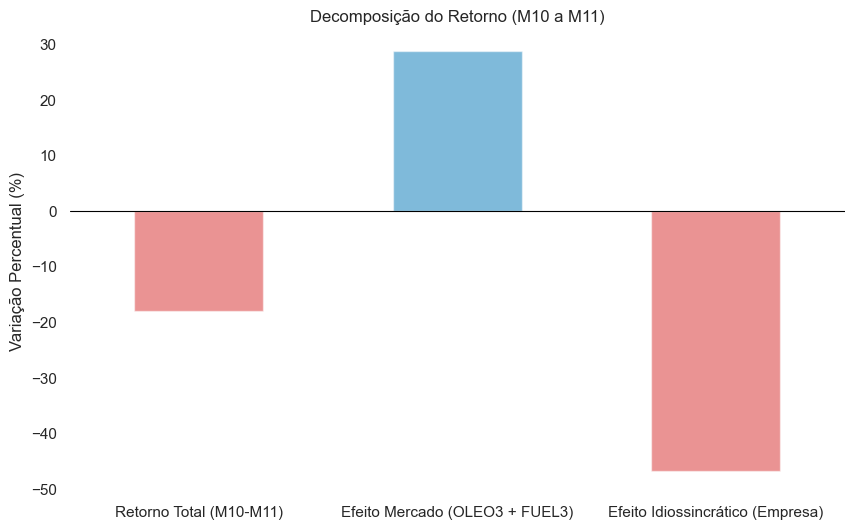

In [108]:
plot_3()

### Observações e Conclusão

A partir das proxies `OLEO3` e `FUEL3`, observamos um cenário macroeconômico amplamente positivo para o setor, com um retorno acumulado de mercado de aproximadamente $28.8\%$.

Contudo, o valor da empresa apresentou uma trajetória divergente, com uma queda real de $18\%$ entre as marcações. A composição do log-retorno nos revela que o fator idiossincrático (específico da empresa) foi o grande detrator de performance, exercendo uma pressão negativa de $-46.8\%$ (log) que anulou por completo a tendência positiva do mercado.

Essa análise confirma a importância da reconciliação Ex Post: sem o ajuste de drift ($\alpha$), a gestão estaria operando com uma estimativa de valor sobrevalorizada, ignorando fatores específicos que não seriam capturados pelas proxies de mercado.